- [Gráfico 1](#gr1): taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


- [Gráfico 2](#gr2): Taxa de utilização de Espaço da Rede: que é quão bem a abordagem está aproveitando o espaço de armazenamento disponível após uma falha na rede. Uma taxa alta indica uma boa utilização dos recursos 

- [Gráfico 3](#gr3): -Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele


- [Gráfico 4](#gr4): - tempo de realocação

### Configuração inicial

Importando bibliotecas necessárias

In [34]:
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd

# import seaborn as sns
# import plotly.graph_objects as go
# import plotly.io as pio
# import plotly.express as px


import warnings

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

### Carregamento dos dados

In [35]:
results_flows_directories = glob.glob(
    "../../results/results_flows*/*"
)  # Caso mude a estrutura dos diretórios, esse caminho deve ser alterado
results_flows_directories

['../../results\\results_flows\\goku_backup_s_50_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\goku_s_50_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\msf_s_50_p_8_sfc_on_rel_1',
 '../../results\\results_flows\\musfico_s_50_p_8_sfc_on_rel_1']

In [36]:
for alg_dir in results_flows_directories:
    simulacoes_okays = 0
    simu_exec_name = alg_dir.split("/")[-1].split("_")

    if simu_exec_name[2] == "backup":
        alg_name = "goku_backup"
    else:
        alg_name = simu_exec_name[1].split("\\")[1]
    reliability = simu_exec_name[-1]

# Gráfico 1 <a id="gr1"></a>

taxa de sucesso na realocação. Usuários afetados que foram realocados devidamente dividido pelo total de usuários afetados


In [37]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")

        if simu_exec_name[2] == "backup":
            alg_name = "goku_backup"
        else:
            alg_name = simu_exec_name[1].split("\\")[1]
        reliability = simu_exec_name[-1]
        if alg_name == "g":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "OSCIM"
        if alg_name == "goku_backup":
            alg_name = "Backup OSCIM"
        if alg_name == "musfico":
            alg_name = "MuSFiCO"

        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {
                "reliability": [reliability],
                "files": len(files),
                "simulacoes_sucesso": 0,
                "Nulos": 0,
            }
        else:
            log_simu[alg_name]["reliability"].append(reliability)
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                # print(simulation_df)
                simulation_df["sfc_id"].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = "sfc_cache_p4_50" in simulation_df["sfc_id"].values
            # print(simulation_is_success)

            if simulation_is_success:
                # Seleciona as métricas relevantes
                simulation_df = simulation_df[metricas_coleta]

                # Remove as linhas onde a coluna 'success' é 'None'
                simulation_df = simulation_df[simulation_df["success"] != "None"]

                # Filtra o DataFrame removendo as linhas onde 'sfc_recovered' é nulo ou 'None'
                recovered_sfcs = simulation_df.dropna(subset=["sfc_recovered"])
                recovered_sfcs = recovered_sfcs[recovered_sfcs["sfc_recovered"] != "None"]

                # Calcula a taxa de recuperação
                recovery_rate = recovered_sfcs["sfc_recovered"].mean() * 100

                # Adiciona a taxa de recuperação ao DataFrame
                simulation_df["recovered_rate"] = recovery_rate

                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df["algorithm"] = alg_name
                simulation_df["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]

                print(simulation_df)
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]["simulacoes_sucesso"] += 1
                log_simu[alg_name]["Nulos"] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [38]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed",
]

In [39]:
aggregated_simulation_data = collect_data_from_alg_directory(
    results_flows_directories, metricas_coleta
)

      number_of_sfc  cpu_utilization  bandwidth_utilization  \
0                 4           0.0083                 0.0000   
1                 4           0.0258                 0.0000   
2                 4           0.0272                 0.0000   
3                 4           0.0447                 0.0000   
4                 4           0.0531                 0.0009   
...             ...              ...                    ...   
2165              4           0.5336                 0.1701   
2166              4           0.5352                 0.1711   
2167              4           0.5542                 0.1731   
2168              4           0.5633                 0.1751   
2169              4           0.5170                 0.1595   

      cache_utilization  latency  decision_time_ms  success  crash_moment  \
0                0.0275      0.0             3.306        1             0   
1                0.0275      0.0             1.943        1             0   
2           

In [40]:
boxplot_df = aggregated_simulation_data.groupby(["algorithm", "simulation"]).mean().reset_index()

In [41]:
boxplot_df

,algorithm,simulation,number_of_sfc,cpu_utilization,bandwidth_utilization,cache_utilization,latency,decision_time_ms,success,crash_moment,recovery_time,sfc_recovered,running_sfcs,running_players,running_sessions,users_crashed,recovered_rate
0,Backup OSCIM,0,4.0,0.782789,0.209957,0.696093,2.199879,4.054325,0.741935,0.008295,0.343121,1.000000,61.811060,33.564055,5.865899,5.023041,100.000000
1,Backup OSCIM,1,4.0,0.790104,0.212409,0.700104,2.155440,3.841389,0.737379,0.002427,0.068296,1.000000,63.057282,35.225728,5.996602,2.909709,100.000000
2,Backup OSCIM,2,4.0,0.775178,0.217148,0.699533,2.176363,3.692629,0.737660,0.007770,0.449460,1.000000,61.085466,34.092779,6.046161,5.545247,100.000000
3,Backup OSCIM,3,4.0,0.789166,0.213369,0.705952,2.248632,3.830971,0.737886,0.002307,0.035482,1.000000,61.590217,33.730964,6.054915,2.034149,100.000000
4,Backup OSCIM,4,4.0,0.800418,0.221869,0.713677,2.199634,3.775918,0.744963,0.004121,0.030865,1.000000,62.327381,34.587454,5.997711,3.032967,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,OSCIM,11,4.0,0.736135,0.213774,0.442619,2.049956,4.602533,0.850224,0.016393,0.936078,1.000000,68.434426,38.004471,5.960507,7.500745,100.000000
72,OSCIM,12,4.0,0.718565,0.218076,0.442235,2.141187,4.314442,0.841787,0.018168,0.930499,0.958333,68.273278,39.126419,5.994701,8.096139,95.833333
73,OSCIM,13,4.0,0.710959,0.210224,0.414901,2.097806,4.644395,0.828767,0.011416,0.493586,1.000000,66.652207,37.548706,5.882801,5.717656,100.000000
74,OSCIM,14,4.0,0.718707,0.221754,0.434912,2.177536,4.653250,0.820283,0.017897,0.791134,1.000000,66.244594,36.274422,6.026100,7.443699,100.000000


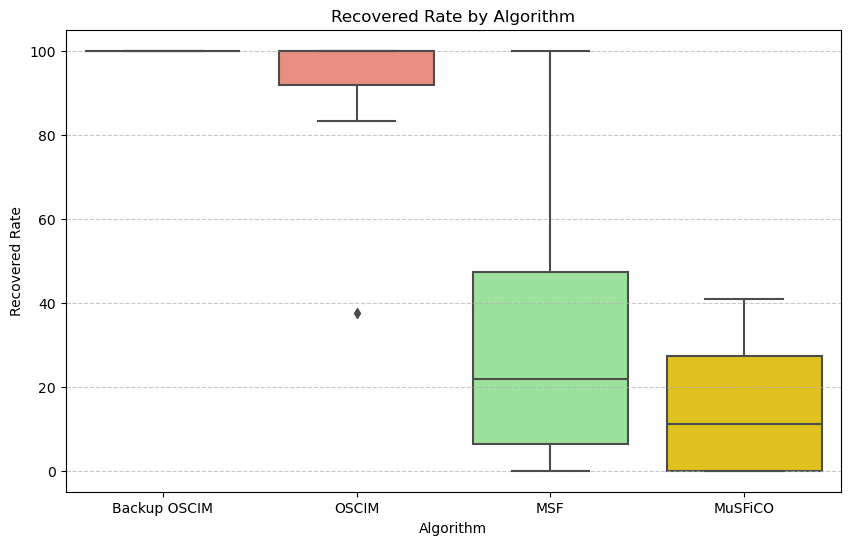

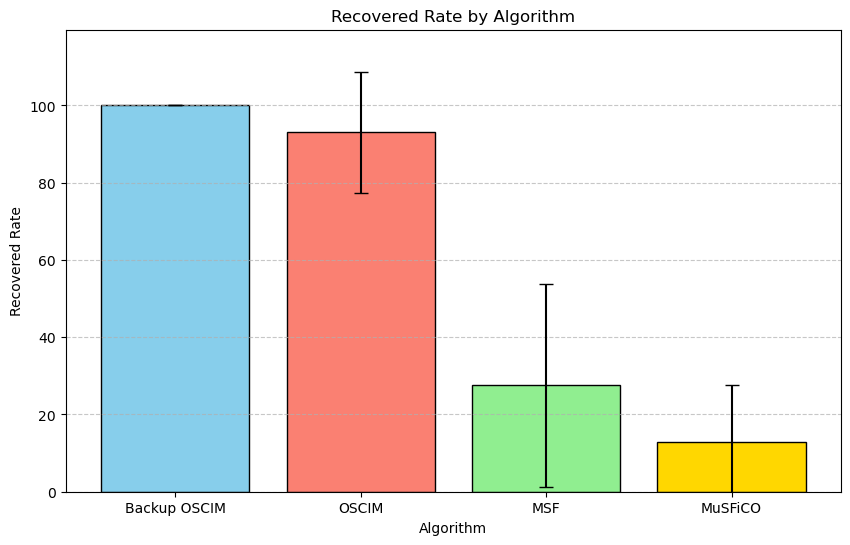

In [42]:
import seaborn as sns

# Ordem dos algoritmos e cores correspondentes
algorithms_order = ["Backup OSCIM", "OSCIM", "MSF", "MuSFiCO"]
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum"]

# Criar um boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y="recovered_rate",
    data=boxplot_df,
    palette=dict(zip(algorithms_order, colors)),
    order=algorithms_order,
)

# Estilizar o gráfico
plt.title("Recovered Rate by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Recovered Rate")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovered_rate_boxplot.pdf")

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão das taxas de recuperação por algoritmo
mean_rates = boxplot_df.groupby("algorithm")["recovered_rate"].mean()
std_rates = boxplot_df.groupby("algorithm")["recovered_rate"].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(
    algorithms_order,
    mean_rates[algorithms_order],
    yerr=std_rates[algorithms_order],
    capsize=5,
    color=colors,
    edgecolor="black",
)

# Estilizar o gráfico
plt.title("Recovered Rate by Algorithm")
plt.xlabel("Algorithm")
plt.ylabel("Recovered Rate")
plt.ylim(0, max(mean_rates + std_rates) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovered_rate_barplot.pdf")

# Exibir a figura
plt.show()

# Gráfico 2 Recovery Time <a id="gr2"></a>

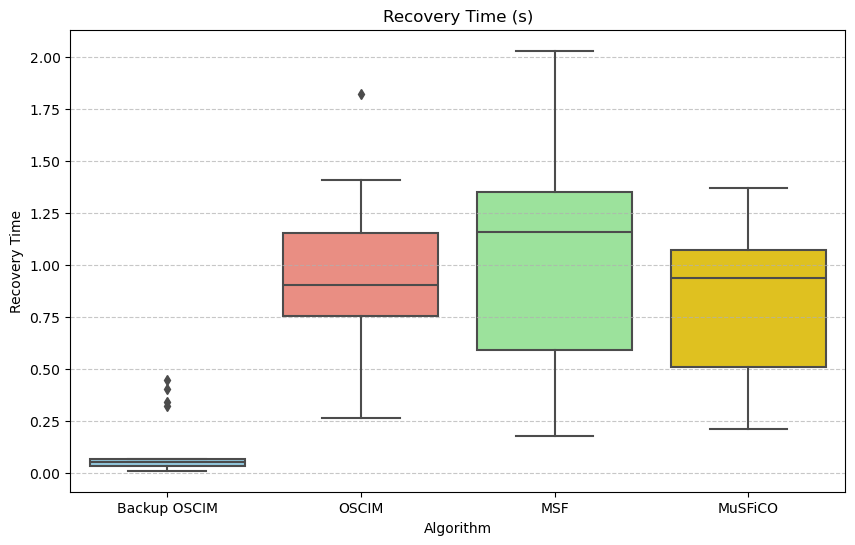

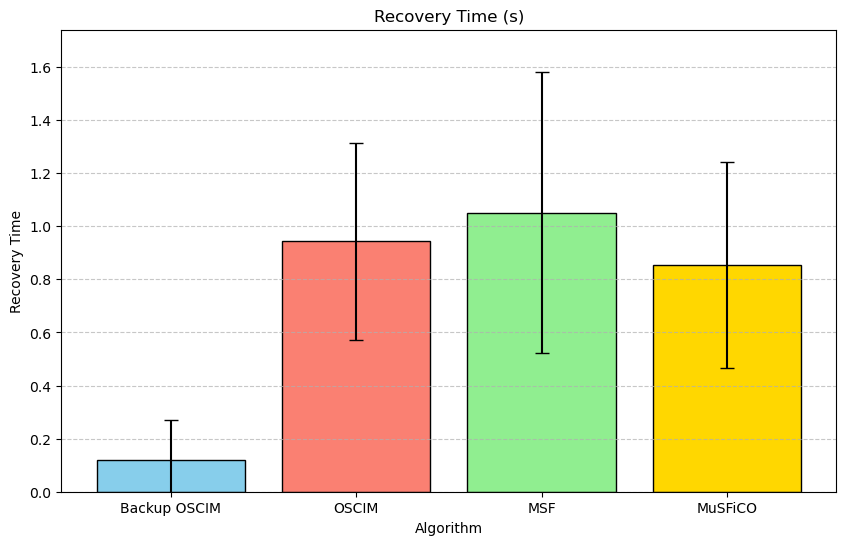

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir a ordem dos algoritmos e as cores correspondentes
algorithms_order = [
    "Backup OSCIM",
    "OSCIM",
    "MSF",
    "MuSFiCO",
]  # Substitua pelos nomes reais dos algoritmos
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "lightcoral"]

# Criar o boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y="recovery_time",
    data=boxplot_df,
    palette=dict(zip(algorithms_order, colors)),
    order=algorithms_order,
)

# Estilizar o gráfico
plt.title("Recovery Time (s)")
plt.xlabel("Algorithm")
plt.ylabel("Recovery Time")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovery_time_boxplot.pdf")

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = boxplot_df.groupby("algorithm")["recovery_time"].mean()
std_times = boxplot_df.groupby("algorithm")["recovery_time"].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(
    algorithms_order,
    mean_times[algorithms_order],
    yerr=std_times[algorithms_order],
    capsize=5,
    color=colors,
    edgecolor="black",
)

# Estilizar o gráfico
plt.title("Recovery Time (s)")
plt.xlabel("Algorithm")
plt.ylabel("Recovery Time")
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovery_time_barplot.pdf")

# Exibir a figura
plt.show()

# Gráfico 3 - latency diff

In [44]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")

        if simu_exec_name[2] == "backup":
            alg_name = "goku_backup"
        else:
            alg_name = simu_exec_name[1].split("\\")[1]
        reliability = simu_exec_name[-1]
        if alg_name == "g":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "OSCIM"
        if alg_name == "goku_backup":
            alg_name = "Backup OSCIM"
        if alg_name == "musfico":
            alg_name = "MuSFiCO"

        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {
                "reliability": [reliability],
                "files": len(files),
                "simulacoes_sucesso": 0,
                "Nulos": 0,
            }
        else:
            log_simu[alg_name]["reliability"].append(reliability)
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                # print(simulation_df)
                simulation_df["sfc_id"].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = "sfc_cache_p4_50" in simulation_df["sfc_id"].values

            if simulation_is_success:
                # Seleciona as métricas relevantes
                simulation_df = simulation_df[metricas_coleta]

                # Remove as linhas onde a coluna 'success' é 'None'
                # simulation_df = simulation_df[simulation_df['success'] != 'None']

                # Filtra o DataFrame removendo as linhas onde 'sfc_recovered' é nulo ou 'None'
                # Filtra o DataFrame removendo as linhas onde 'latency_diff' é nulo ou 'None'
                simulation_df = simulation_df.dropna(subset=["latency_diff"])
                simulation_df = simulation_df[simulation_df["latency_diff"] != "None"]

                # Converte a coluna 'latency_diff' para valores numéricos (caso não esteja)
                simulation_df["latency_diff"] = pd.to_numeric(
                    simulation_df["latency_diff"], errors="coerce"
                )

                # Remove linhas com valores nulos após a conversão
                simulation_df = simulation_df.dropna(subset=["latency_diff"])

                # Calcula a média de 'latency_diff'
                latency_diff_mean = simulation_df["latency_diff"].mean()
                simulation_df["benefit_loss_rate"] = (simulation_df["latency_diff"] - 6) / -12
                # Define o nome do algoritmo e incrementa a contagem de simulações
                simulation_df["latency_diff"] = latency_diff_mean
                simulation_df["algorithm"] = alg_name
                simulation_df["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]

                # Calcula a nova coluna 'benefit_loss_rate' com a fórmula especificad

                # print(simulation_df)
                data_nla.append(simulation_df)

                # Incrementa a contagem de simulações de sucesso e soma os valores nulos
                log_simu[alg_name]["simulacoes_sucesso"] += 1
                log_simu[alg_name]["Nulos"] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [45]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "decision_time_ms",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "users_crashed",
    "latency_diff",
]

In [46]:
aggregated_simulation_data = collect_data_from_alg_directory(
    results_flows_directories, metricas_coleta
)


Resumo das Simulações:
Algoritmo: Backup OSCIM
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 19
  Dados nulos: 0

Algoritmo: OSCIM
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 16
  Dados nulos: 0

Algoritmo: MSF
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 24
  Dados nulos: 0

Algoritmo: MuSFiCO
  Confiabilidades: ['1']
  Quantidade de arquivos: 30
  Simulações de sucesso: 17
  Dados nulos: 0



In [47]:
boxplot_df_2 = aggregated_simulation_data.groupby(["algorithm", "simulation"]).mean().reset_index()

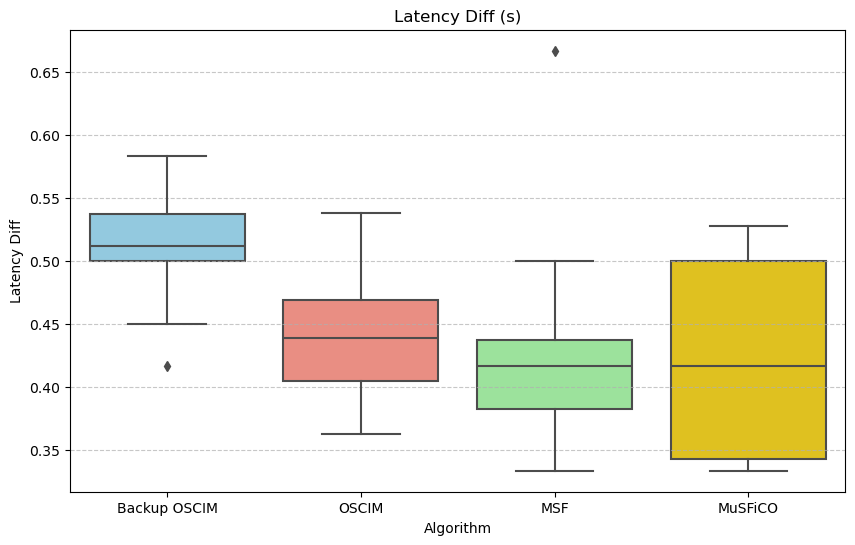

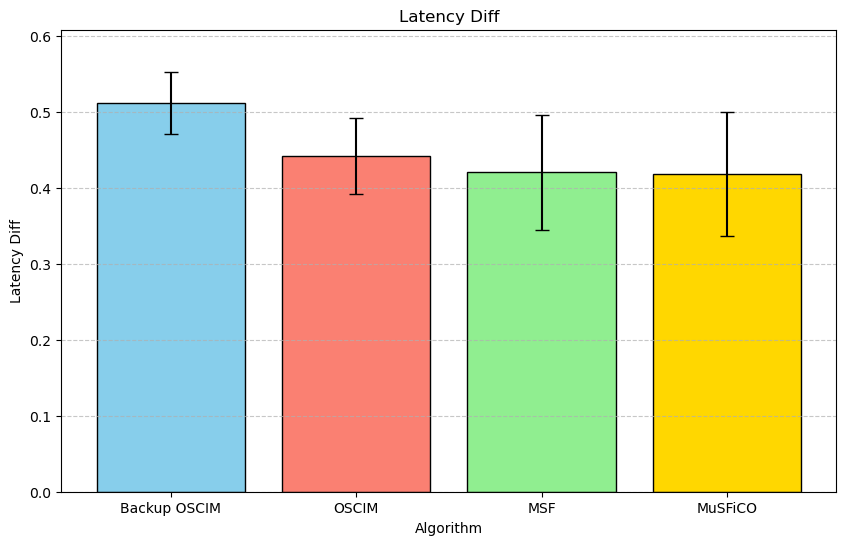

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir a ordem dos algoritmos e as cores correspondentes
algorithms_order = [
    "Backup OSCIM",
    "OSCIM",
    "MSF",
    "MuSFiCO",
]  # Substitua pelos nomes reais dos algoritmos
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "lightcoral"]

# Criar o boxplot usando seaborn com a paleta de cores correspondente
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="algorithm",
    y="benefit_loss_rate",
    data=boxplot_df_2,
    palette=dict(zip(algorithms_order, colors)),
    order=algorithms_order,
)

# Estilizar o gráfico
plt.title("Latency Diff (s)")
plt.xlabel("Algorithm")
plt.ylabel("Latency Diff")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("latency_diff_boxplot.pdf")

# Exibir a figura
plt.show()

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = boxplot_df_2.groupby("algorithm")["benefit_loss_rate"].mean()
std_times = boxplot_df_2.groupby("algorithm")["benefit_loss_rate"].std()

# Criar um barplot usando matplotlib com as mesmas cores e ordem de algoritmos
plt.figure(figsize=(10, 6))
bars = plt.bar(
    algorithms_order,
    mean_times[algorithms_order],
    yerr=std_times[algorithms_order],
    capsize=5,
    color=colors,
    edgecolor="black",
)

# Estilizar o gráfico
plt.title("Latency Diff")
plt.xlabel("Algorithm")
plt.ylabel("Latency Diff")
plt.ylim(0, max(mean_times + std_times) * 1.1)  # Ajustar o limite superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("latency_diff_barplot.pdf")

# Exibir a figura
plt.show()

# Gráfico 3 <a id="gr3"></a>

Taxa de perda de benefícios: O quão o usuário foi prejudicado nessa realocação em comparação com a alocação antiga dele

In [ ]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        # print(simu_exec_name)
        alg_name = simu_exec_name[1].split("\\")[1]
        reliability = simu_exec_name[-1]
        if alg_name == "g":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "Goku"
        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {
                "reliability": [reliability],
                "files": len(files),
                "simulacoes_sucesso": 0,
                "Nulos": 0,
            }
        else:
            log_simu[alg_name]["reliability"].append(reliability)
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                # print(simulation_df)
                simulation_df["sfc_id"].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = "sfc_cache_p4_50" in simulation_df["sfc_id"].values
            # print(simulation_is_success)
            if simulation_is_success:
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df["success"]):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))

                simulation_df["success"] = cumulative_avg_success
                # Criar a nova coluna com zeros

                # Criar a nova coluna com zeros
                simulation_df["latency_diff"] = 0
                simulation_df["benefit_loss_rate"] = 0

                # Filtrar os valores não nulos e diferentes de zero na coluna 'latency'
                valid_latencies = simulation_df["latency"].replace(0, pd.NA).dropna()

                # Definir a latência mínima possível (ideal, sem falha)
                latency_min = valid_latencies.min()

                # Dicionário para armazenar a última latência de cada sfc_id
                last_latency = {}

                # Percorrer o DataFrame para calcular as diferenças de latência e a taxa de perda de benefício
                for index, row in simulation_df.iterrows():
                    sfc_id = row["sfc_id"]
                    latency = row["latency"]
                    success = row["success"]

                    if success:
                        if sfc_id in last_latency:
                            latency_diff = latency - last_latency[sfc_id]
                            simulation_df.at[index, "latency_diff"] = latency_diff
                            benefit_loss_rate = latency_diff / latency_min
                            simulation_df.at[index, "benefit_loss_rate"] = benefit_loss_rate
                        last_latency[sfc_id] = latency

                # Calcular ORub como a soma das latências mínimas por sfc_id
                ORub = simulation_df.groupby("sfc_id")["latency"].min().sum()

                # Calcular OR como a soma das latências atuais
                ORe = simulation_df["latency"].sum()
                benefit_loss_rate = (ORub - ORe) / ORub
                simulation_df["benefit_loss_rate_2"] = benefit_loss_rate

                simulation_df = simulation_df.dropna()

                # recovered_sfcs = simulation_df['sfc_recovered'].dropna()
                # if alg_name == 'g':
                #     print(recovered_sfcs)
                #     print(file)

                # recovery_rate = recovered_sfcs.mean() * 100

                # simulation_df['recovered_rate'] = recovery_rate
                simulation_df["algorithm"] = alg_name
                simulation_df["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]

                data_nla.append(simulation_df)

                log_simu[alg_name]["simulacoes_sucesso"] = (
                    log_simu[alg_name]["simulacoes_sucesso"] + 1
                )
                log_simu[alg_name]["Nulos"] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [ ]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id",
]

aggregated_simulation_data = collect_data_from_alg_directory(
    results_flows_directories, metricas_coleta
)

In [ ]:
aggregated_simulation_data

In [ ]:
grouped_df_3 = aggregated_simulation_data.groupby(["algorithm", "simulation"]).mean(
    numeric_only=True
)

In [ ]:
grouped_df_3["Relocation Cost2"] = (
    (grouped_df_3["benefit_loss_rate_2"] - grouped_df_3["benefit_loss_rate_2"].min())
    / (grouped_df_3["benefit_loss_rate_2"].max() - grouped_df_3["benefit_loss_rate_2"].min())
) * 100

In [ ]:
grouped_df_3["Relocation Cost"] = (
    (grouped_df_3["latency_diff"] - grouped_df_3["latency_diff"].min())
    / (grouped_df_3["latency_diff"].max() - grouped_df_3["latency_diff"].min())
) * 100

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x="algorithm", y="Relocation Cost2", data=grouped_df_3, palette="Set1")

# Estilizar o gráfico
plt.title("Benefit Loss Rate")
plt.xlabel("Algorithm")
plt.ylabel("Benefit Loss Rate")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("Benefit_Loss_Rate.pdf")

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos custos de relocação por algoritmo
mean_relocation_cost = grouped_df_3.groupby("algorithm")["Relocation Cost2"].mean()
std_relocation_cost = grouped_df_3.groupby("algorithm")["Relocation Cost2"].std()

# Definir cores diferentes para cada algoritmo
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "lightcoral"]

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(
    mean_relocation_cost.index,
    mean_relocation_cost,
    yerr=std_relocation_cost,
    capsize=5,
    color=colors,
    edgecolor="black",
)

# Estilizar o gráfico
plt.title("Benefit Loss Rate")
plt.xlabel("Algorithm")
plt.ylabel("Benefit Loss Rate")
plt.ylim(
    0, max(mean_relocation_cost + std_relocation_cost) * 1.1
)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("Benefit_Loss_Rate_barplot.pdf")

# Exibir a figura
plt.show()

# Gráfico 4 <a id="gr4"></a>

In [ ]:
aggregated_simulation_data = pd.DataFrame()
algos = {}


def collect_data_from_alg_directory(results_flows_directories, metricas_coleta):
    data_nla = []
    log_simu = {}  # Essa variável serve apenas para verificar as simulações

    for alg_dir in results_flows_directories:
        simu_exec_name = alg_dir.split("/")[-1].split("_")
        # print(simu_exec_name)
        alg_name = simu_exec_name[1].split("\\")[1]
        reliability = simu_exec_name[-1]
        if alg_name == "g":
            alg_name = "Greedy"
        if alg_name == "ga":
            alg_name = "GA"
        if alg_name == "msf":
            alg_name = "MSF"
        if alg_name == "goku":
            alg_name = "Goku"
        files = os.listdir(alg_dir)
        # print(f"Simulação: {alg_name}, {reliability}")
        # print("Quantidade de csv: ", len(files))

        if alg_name not in log_simu:
            log_simu[alg_name] = {
                "reliability": [reliability],
                "files": len(files),
                "simulacoes_sucesso": 0,
                "Nulos": 0,
            }
        else:
            log_simu[alg_name]["reliability"].append(reliability)
            log_simu[alg_name]["files"] += len(files)

        for file in files:
            data_path = os.path.join(alg_dir, file)
            try:
                simulation_df = pd.read_csv(data_path)
                # print(simulation_df)
                simulation_df["sfc_id"].values
            except Exception as e:
                print(f"Erro ao ler o arquivo {file}: {e}")
                continue

            simulation_is_success = "sfc_cache_p4_50" in simulation_df["sfc_id"].values
            # print(simulation_is_success)
            if simulation_is_success:
                # Calcular média acumulada de 'success'
                simulation_df = simulation_df[metricas_coleta]
                cumulative_sum_success = 0
                cumulative_avg_success = []
                for i, value in enumerate(simulation_df["success"]):
                    cumulative_sum_success += value
                    cumulative_avg_success.append(cumulative_sum_success / (i + 1))

                simulation_df["success"] = cumulative_avg_success
                execution_time = simulation_df["duration"].mean()
                simulation_df = simulation_df[simulation_df["recovery_time"] != 0]
                for i in simulation_df["recovery_time"]:
                    print(i)
                recovery_mean = simulation_df["recovery_time"].mean()
                running_sfcs_mean = simulation_df["running_sfcs"].mean()
                recovery_time_per_sfc = (
                    recovery_mean / running_sfcs_mean if running_sfcs_mean != 0 else 0
                )

                if recovery_time_per_sfc == 0:
                    continue

                simulation_df["recovery_time_per_sfc"] = recovery_time_per_sfc
                simulation_df["recovery_time"] = recovery_mean
                simulation_df["execution_time"] = execution_time
                simulation_df["algorithm"] = alg_name
                simulation_df["simulation"] = log_simu[alg_name]["simulacoes_sucesso"]

                data_nla.append(simulation_df)

                log_simu[alg_name]["simulacoes_sucesso"] = (
                    log_simu[alg_name]["simulacoes_sucesso"] + 1
                )
                log_simu[alg_name]["Nulos"] += sum(simulation_df.isnull().sum())

    if data_nla:
        data_nla_f = pd.concat(data_nla)
    else:
        data_nla_f = pd.DataFrame()

    print("\nResumo das Simulações:")
    for alg, info in log_simu.items():
        print(f"Algoritmo: {alg}")
        print(f"  Confiabilidades: {info['reliability']}")
        print(f"  Quantidade de arquivos: {info['files']}")
        print(f"  Simulações de sucesso: {info['simulacoes_sucesso']}")
        print(f"  Dados nulos: {info['Nulos']}")
        print()

    return data_nla_f

In [ ]:
metricas_coleta = [
    "number_of_sfc",
    "cpu_utilization",
    "bandwidth_utilization",
    "cache_utilization",
    "latency",
    "duration",
    "success",
    "crash_moment",
    "recovery_time",
    "sfc_recovered",
    "running_sfcs",
    "running_players",
    "running_sessions",
    "server_crashed",
    "users_crashed",
    "sfc_id",
]

aggregated_simulation_data = collect_data_from_alg_directory(
    results_flows_directories, metricas_coleta
)

In [ ]:
aggregated_simulation_data

In [ ]:
grouped_df_4 = (
    aggregated_simulation_data[aggregated_simulation_data["recovery_time"] != 0]
    .groupby(["algorithm", "simulation"])
    .mean(numeric_only=True)
    .reset_index()
)

In [ ]:
grouped_df_4

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x="algorithm", y="recovery_time_per_sfc", data=grouped_df_4, palette="Set1")

# Estilizar o gráfico
plt.title("Recovery Time (s)")
plt.xlabel("Algorithm")
plt.ylabel("Recovery Time")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovery_time.pdf")

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão dos tempos de recuperação por algoritmo
mean_times = grouped_df_4.groupby("algorithm")["recovery_time_per_sfc"].mean()
std_times = grouped_df_4.groupby("algorithm")["recovery_time_per_sfc"].std()

# Definir cores diferentes para cada algoritmo
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "lightcoral"]

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(
    mean_times.index, mean_times, yerr=std_times, capsize=5, color=colors, edgecolor="black"
)

# Estilizar o gráfico
plt.title("Recovery Time (s)")
plt.xlabel("Algorithm")
plt.ylabel("Recovery Time")
plt.ylim(
    0, max(mean_times + std_times) * 1.1
)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("recovery_time_barplot.pdf")

# Exibir a figura
plt.show()

# Gráfico 5

In [ ]:
boxplot_df["success"] = boxplot_df["success"] * 100

In [ ]:
# Criar o boxplot usando seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x="algorithm", y="success", data=boxplot_df, palette="Set1")

# Estilizar o gráfico
plt.title("Success")
plt.xlabel("Algorithm")
plt.ylabel("Acceptance Ratio (%)")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("Acceptance.pdf")

# Exibir a figura
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Calcular a média e o desvio padrão das taxas de sucesso por algoritmo
mean_success = boxplot_df.groupby("algorithm")["success"].mean()
std_success = boxplot_df.groupby("algorithm")["success"].std()

# Definir cores diferentes para cada algoritmo
colors = ["skyblue", "salmon", "lightgreen", "gold", "plum", "lightcoral"]

# Criar um barplot usando matplotlib
plt.figure(figsize=(10, 6))
bars = plt.bar(
    mean_success.index, mean_success, yerr=std_success, capsize=5, color=colors, edgecolor="black"
)

# Estilizar o gráfico
plt.title("Success")
plt.xlabel("Algorithm")
plt.ylabel("Acceptance Ratio (%)")
plt.ylim(
    0, max(mean_success + std_success) * 1.1
)  # Ajustar o limite inferior para 0 e o superior com uma margem

# Adicionar grade
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Salvar a figura
plt.savefig("Acceptance_barplot.pdf")

# Exibir a figura
plt.show()